In [99]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch.nn.functional as F


MODEL_NAME = "arnir0/Tiny-LLM"
#MODEL_NAME = "weiser/101M-0.4" 


In [100]:

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.config._attn_implementation = "eager"

Loading weights: 100%|██████████| 12/12 [00:00<00:00, 277.66it/s]


In [101]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left" 

In [102]:
vocab = tokenizer.get_vocab()

In [103]:
print(vocab["ivan"])

20595


In [104]:
def generate_text(prompt, model, tokenizer, max_length=32, temperature=1, top_k=50, top_p=0.95):

    tokens = tokenizer.tokenize(prompt)
    print(tokens)

    ids = torch.tensor([tokenizer.convert_tokens_to_ids(tokens)])
    print(ids)

    inputs = tokenizer.encode(prompt, return_tensors="pt")
    print(input)

    outputs = model.generate(
        ids,
        max_length=max_length,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
        do_sample=True
    )


    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return generated_text

In [105]:
model


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 192)
    (layers): ModuleList(
      (0): LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=192, out_features=192, bias=False)
          (k_proj): Linear(in_features=192, out_features=96, bias=False)
          (v_proj): Linear(in_features=192, out_features=96, bias=False)
          (o_proj): Linear(in_features=192, out_features=192, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=192, out_features=1024, bias=False)
          (up_proj): Linear(in_features=192, out_features=1024, bias=False)
          (down_proj): Linear(in_features=1024, out_features=192, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((192,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((192,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((192,), eps=1e-05)
    (rotary_emb): LlamaRotaryEm

In [106]:
prompt = "i think that 2 x 2 equals to "

In [107]:
s = len(tokenizer.tokenize(prompt))
l = 1
generated_text = generate_text(prompt, model, tokenizer, s+l)

print("\n" + generated_text)

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


['▁i', '▁think', '▁that', '▁', '2', '▁x', '▁', '2', '▁equals', '▁to', '▁']
tensor([[  474,  1348,   393, 29871, 29906,   921, 29871, 29906, 15743,   304,
         29871]])
<bound method Kernel.raw_input of <ipykernel.ipkernel.IPythonKernel object at 0x1083abb60>>

i think that 2 x 2 equals to 7


In [108]:
tokens = tokenizer.tokenize(prompt)
print(tokens)

ids = torch.tensor([tokenizer.convert_tokens_to_ids(tokens)])
print(ids)

print(tokenizer.encode(prompt, return_tensors="pt"))


['▁i', '▁think', '▁that', '▁', '2', '▁x', '▁', '2', '▁equals', '▁to', '▁']
tensor([[  474,  1348,   393, 29871, 29906,   921, 29871, 29906, 15743,   304,
         29871]])
tensor([[    1,   474,  1348,   393, 29871, 29906,   921, 29871, 29906, 15743,
           304, 29871]])


In [109]:
outputs = model(ids, 
                output_attentions=True,
                output_hidden_states=True,
                return_dict=True)

print(outputs)
attn = outputs.attentions[0]
print(attn[0][0])


CausalLMOutputWithPast(loss=None, logits=tensor([[[ -4.9328,  -4.9131,   4.0986,  ...,  -4.5852,  -4.7602,  -4.6154],
         [ -6.5063,  -6.4896,   4.0434,  ...,  -5.6100,  -6.4286,  -5.9517],
         [-10.9226, -10.9248,  -0.2742,  ..., -10.2936, -10.8424, -10.5389],
         ...,
         [-16.9741, -16.9502,  -0.3081,  ..., -14.2846, -16.4793, -14.5106],
         [-15.6503, -15.6351,  -3.0483,  ..., -13.3637, -15.2019, -13.7880],
         [ -8.6843,  -8.6758,   1.5806,  ...,  -6.8307,  -8.3648,  -7.1536]]],
       grad_fn=<UnsafeViewBackward0>), past_key_values=DynamicCache(layers=[DynamicLayer]), hidden_states=(tensor([[[-1.3321e-02,  4.6631e-02,  5.5313e-03,  ..., -4.1901e-02,
           3.2928e-02, -3.5004e-02],
         [ 1.6724e-02,  5.6305e-02, -5.5275e-03,  ..., -3.0624e-02,
           6.4331e-02,  1.6113e-02],
         [-1.2520e-02,  6.9580e-03, -3.6163e-02,  ...,  2.3544e-02,
           6.5979e-02, -7.4539e-03],
         ...,
         [ 1.4145e-02,  2.3727e-02, -1.1536e-

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [111]:
def draw_att(attn, labels, size=(6,5)):
    heads = attn[0].detach().cpu().to(torch.float32).numpy()

    for i, head_matrix in enumerate(heads):
        plt.figure(figsize=size)
        plt.title(f"Attention Head {i}") 
        if len(labels) > 0:
            sns.heatmap(head_matrix, xticklabels=labels, yticklabels=labels)
        else:
            sns.heatmap(head_matrix)
        plt.show()


In [112]:
hs = outputs.hidden_states
embs = hs[0]
l0 = hs[1]

In [113]:
layer = model.model.layers[0]
x = embs
x_norm = layer.input_layernorm(x)

In [114]:
# --- 1. Self-attention руками ---
q = layer.self_attn.q_proj(x_norm)   # [1, seq, 192]
k = layer.self_attn.k_proj(x_norm)   # [1, seq, 96]  (GQA: меньше heads у k/v)
v = layer.self_attn.v_proj(x_norm)   # [1, seq, 96]

print("q shape:", q.shape)
print("k shape:", k.shape)
print("v shape:", v.shape)

q shape: torch.Size([1, 11, 192])
k shape: torch.Size([1, 11, 96])
v shape: torch.Size([1, 11, 96])


In [115]:
# --- 2. Reshape на головы ---
bsz, seq_len, _ = x_norm.shape

num_heads = model.config.num_attention_heads
num_kv_heads = model.config.num_key_value_heads
head_dim = model.config.hidden_size // num_heads

print("num_heads:", num_heads, "num_kv_heads:", num_kv_heads, "head_dim:", head_dim)

q = q.view(bsz, seq_len, num_heads, head_dim).transpose(1, 2)       # [1, num_heads, seq, head_dim]
k = k.view(bsz, seq_len, num_kv_heads, head_dim).transpose(1, 2)    # [1, num_kv_heads, seq, head_dim]
v = v.view(bsz, seq_len, num_kv_heads, head_dim).transpose(1, 2)    # [1, num_kv_heads, seq, head_dim]

print("q reshaped:", q.shape)
print("k reshaped:", k.shape)

num_heads: 2 num_kv_heads: 1 head_dim: 96
q reshaped: torch.Size([1, 2, 11, 96])
k reshaped: torch.Size([1, 1, 11, 96])


In [116]:
# --- 3. Применяем RoPE (Rotary Positional Embedding) ---
position_ids = torch.arange(seq_len).unsqueeze(0)  # [1, seq]

cos, sin = model.model.rotary_emb(v, position_ids)  # v передаём просто чтобы взять dtype/device

def rotate_half(t):
    t1, t2 = t.chunk(2, dim=-1)
    return torch.cat((-t2, t1), dim=-1)

def apply_rope(t, cos, sin):
    cos = cos.unsqueeze(1)  # [1, 1, seq, head_dim] чтобы broadcast по heads
    sin = sin.unsqueeze(1)
    return (t * cos) + (rotate_half(t) * sin)

q_rot = apply_rope(q, cos, sin)
k_rot = apply_rope(k, cos, sin)

print("q_rot:", q_rot.shape)

q_rot: torch.Size([1, 2, 11, 96])


In [117]:
# --- 4. GQA: повторяем k/v чтобы совпадало число heads с q ---
n_rep = num_heads // num_kv_heads
print("n_rep (групп на 1 kv-голову):", n_rep)

def repeat_kv(t, n_rep):
    b, n_kv, s, d = t.shape
    if n_rep == 1:
        return t
    t = t[:, :, None, :, :].expand(b, n_kv, n_rep, s, d)
    return t.reshape(b, n_kv * n_rep, s, d)

k_rep = repeat_kv(k_rot, n_rep)
v_rep = repeat_kv(v, n_rep)

print("k_rep:", k_rep.shape)

# --- 5. Скалярное произведение Q*K^T / sqrt(head_dim) ---
scores = torch.matmul(q_rot, k_rep.transpose(-2, -1)) / (head_dim ** 0.5)  # [1, num_heads, seq, seq]
print("scores shape:", scores.shape)

n_rep (групп на 1 kv-голову): 2
k_rep: torch.Size([1, 2, 11, 96])
scores shape: torch.Size([1, 2, 11, 11])


In [118]:
# --- 6. Causal mask ---
causal_mask = torch.full((seq_len, seq_len), float("-inf"))
causal_mask = torch.triu(causal_mask, diagonal=1)  # верхний треугольник -inf, остальное 0
scores_masked = scores + causal_mask

attn_weights_manual = F.softmax(scores_masked, dim=-1)

# Сверка с тем, что выдал outputs.attentions[0] (это и есть attn в вашей ячейке 10)
print("max abs diff vs outputs.attentions[0]:",
      (attn_weights_manual - attn[0]).abs().max().item())

max abs diff vs outputs.attentions[0]: 5.960464477539063e-08


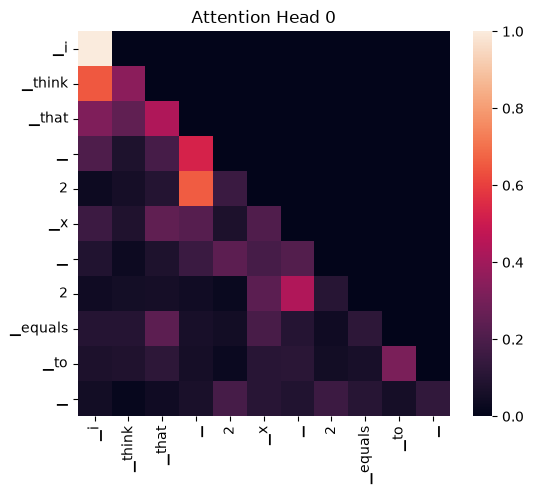

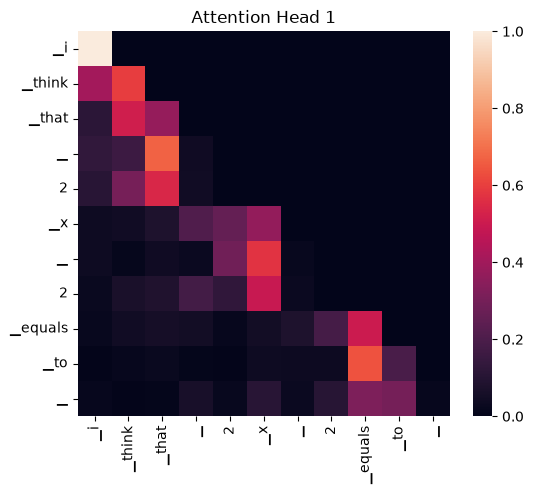

In [119]:
attn_weights_manual.shape
labels = tokenizer.convert_ids_to_tokens(ids[0])
draw_att(attn_weights_manual, labels)

In [120]:
causal_mask

tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [121]:
# --- 7. attn_weights @ V, затем склеиваем головы и o_proj ---
attn_out = torch.matmul(attn_weights_manual, v_rep)               # [1, num_heads, seq, head_dim]
attn_out.shape

torch.Size([1, 2, 11, 96])

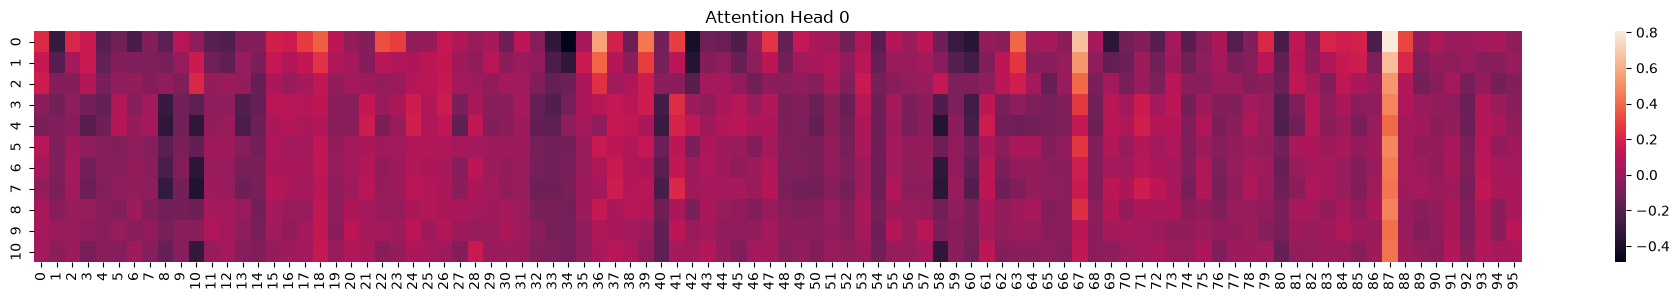

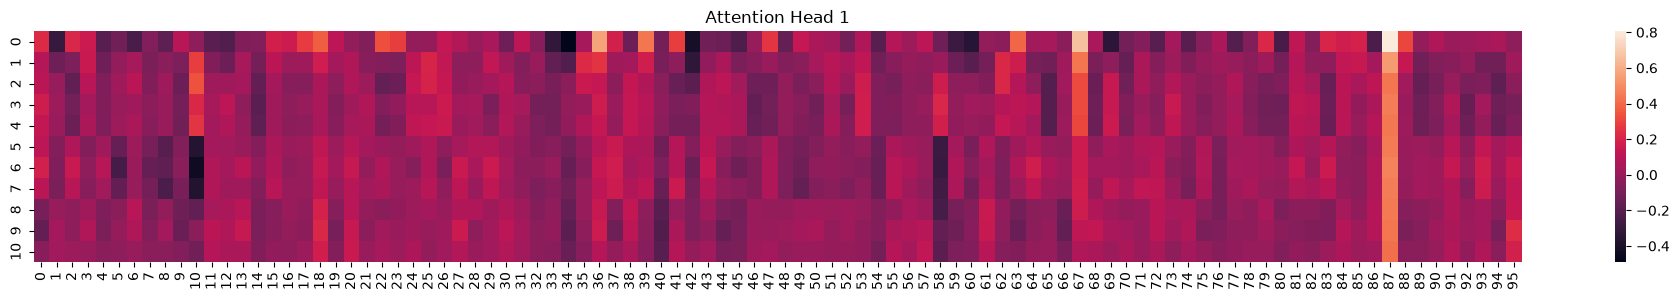

In [122]:
draw_att(attn_out, [], (24, 3))

In [123]:

attn_out = attn_out.transpose(1, 2).contiguous()                  # [1, seq, num_heads, head_dim]
attn_out = attn_out.reshape(bsz, seq_len, -1)                     # [1, seq, hidden_size]

attn_out = layer.self_attn.o_proj(attn_out)                       # [1, seq, hidden_size]
print("attn_out shape:", attn_out.shape)

attn_out shape: torch.Size([1, 11, 192])


In [124]:
# --- 8. Первый residual connection ---
hidden_after_attn = x + attn_out   # x — исходный вход слоя (до input_layernorm!)
print("hidden_after_attn shape:", hidden_after_attn.shape)

hidden_after_attn shape: torch.Size([1, 11, 192])


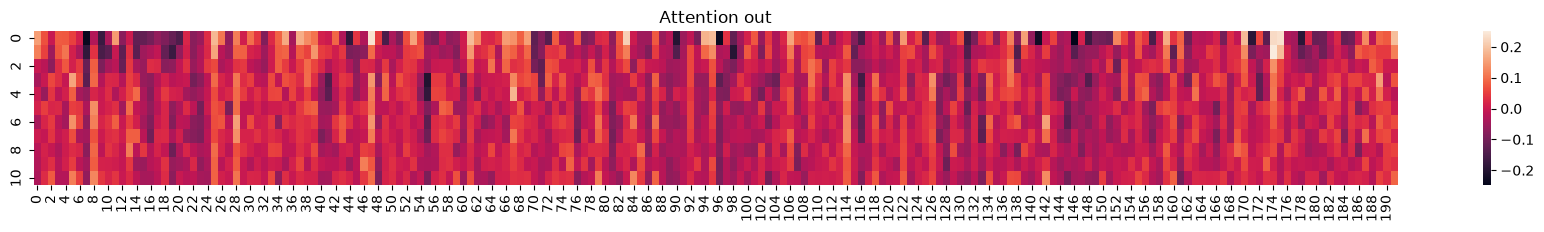

In [125]:
h = hidden_after_attn[0].detach().cpu().to(torch.float32).numpy()

plt.figure(figsize=(22, 2))
plt.title(f"Attention out") 
sns.heatmap(h)
plt.show()

In [126]:
import torch.nn.functional as F

def nearest_tokens(hidden_states, embed_weight, tokenizer, top_k=5):
    """
    hidden_states: [1, seq_len, hidden_size] — например, hidden_after_attn
    embed_weight: матрица эмбеддингов модели, [vocab_size, hidden_size]
    Возвращает для каждой позиции top_k ближайших токенов по косинусному сходству.
    """
    hs = hidden_states[0]  # [seq_len, hidden_size]

    # Косинусное сходство: нормализуем оба пространства и берём скалярное произведение
    hs_norm = F.normalize(hs, dim=-1)                  # [seq_len, hidden_size]
    emb_norm = F.normalize(embed_weight, dim=-1)        # [vocab_size, hidden_size]

    sims = torch.matmul(hs_norm, emb_norm.T)            # [seq_len, vocab_size]

    results = []
    for pos in range(hs.shape[0]):
        top_vals, top_idx = torch.topk(sims[pos], top_k)
        top_tokens = tokenizer.convert_ids_to_tokens(top_idx.tolist())
        results.append(list(zip(top_tokens, top_vals.tolist())))
    return results

In [127]:
embed_weight = model.model.embed_tokens.weight.detach()
nearest = nearest_tokens(hidden_after_attn.detach(), embed_weight, tokenizer, top_k=5)

for pos, (orig_token, candidates) in enumerate(zip(labels, nearest)):
    print(f"[{pos}] исходный токен: {orig_token!r}")
    for tok, sim in candidates:
        print(f"      {tok!r:20s} cos_sim={sim:.4f}")
    print()

[0] исходный токен: '▁i'
      '<0xFC>'             cos_sim=0.1787
      '▁Населення'         cos_sim=0.1784
      '▁насеља'            cos_sim=0.1779
      '$}}%'               cos_sim=0.1716
      '<0x5C>'             cos_sim=0.1686

[1] исходный токен: '▁think'
      '▁think'             cos_sim=0.3182
      '▁thinks'            cos_sim=0.2738
      'нім'                cos_sim=0.2314
      '▁guessing'          cos_sim=0.2115
      'ствовал'            cos_sim=0.1973

[2] исходный токен: '▁that'
      'нім'                cos_sim=0.2225
      '▁that'              cos_sim=0.2187
      '<>();'              cos_sim=0.2067
      'ствовал'            cos_sim=0.1994
      '}}_{\\'             cos_sim=0.1932

[3] исходный токен: '▁'
      '▁'                  cos_sim=0.4974
      '▁$'                 cos_sim=0.3273
      '▁£'                 cos_sim=0.2550
      '▁$-'                cos_sim=0.2440
      '▁március'           cos_sim=0.2399

[4] исходный токен: '2'
      '▁Sept'             

In [128]:
# --- 9. post_attention_layernorm + MLP (SwiGLU) ---
residual2 = hidden_after_attn
x_norm2 = layer.post_attention_layernorm(hidden_after_attn)

gate = layer.mlp.gate_proj(x_norm2)
up = layer.mlp.up_proj(x_norm2)
gate_act = F.silu(gate)            # SiLU(x) = x * sigmoid(x)
intermediate = gate_act * up
mlp_out = layer.mlp.down_proj(intermediate)

print("mlp_out shape:", mlp_out.shape)

mlp_out shape: torch.Size([1, 11, 192])


In [129]:
# --- 10. Второй residual connection — итог одного decoder layer ---
manual_l0 = residual2 + mlp_out

print("max abs diff vs hs[1] (эталон от model()):",
      (manual_l0 - l0).abs().max().item())
manual_l0

max abs diff vs hs[1] (эталон от model()): 19.631690979003906


tensor([[[ 0.2765,  0.1266,  0.0943,  ...,  0.1157, -0.1011,  0.0927],
         [ 0.0915,  0.2358, -0.1213,  ...,  0.1992,  0.0308,  0.0511],
         [-0.0413,  0.2052, -0.1883,  ...,  0.1510, -0.0349,  0.0394],
         ...,
         [-0.0607,  0.0560,  0.0994,  ...,  0.1086, -0.0193,  0.0145],
         [-0.0148,  0.0393,  0.0062,  ...,  0.1193,  0.0168, -0.0522],
         [-0.2092, -0.0992,  0.0885,  ...,  0.2827,  0.0587, -0.2322]]],
       grad_fn=<AddBackward0>)

In [130]:
# --- 11. Если это последний слой: финальный RMSNorm + lm_head ---
final_norm = model.model.norm(manual_l0)
logits_manual = model.lm_head(final_norm)

print("max abs diff vs outputs.logits:",
      (logits_manual - outputs.logits).abs().max().item())

max abs diff vs outputs.logits: 1.9073486328125e-05
